In [2]:
# Run once if not already installed
# !pip install opencv-python matplotlib numpy pillow ultralytics requests

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def show(img_bgr, title=""):
    """Helper: display an OpenCV (BGR) image correctly in matplotlib (RGB)."""
    plt.figure(figsize=(6, 6))

    if len(img_bgr.shape) == 2:
        plt.imshow(img_bgr, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis('off')
    plt.show()

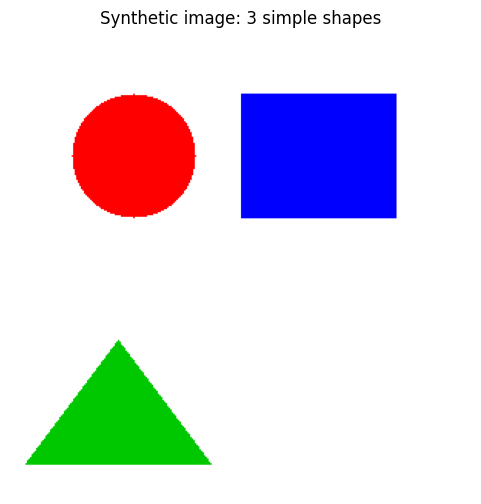

In [3]:
canvas = np.full((300, 300, 3), 255, dtype=np.uint8)  # white background

cv2.circle(canvas, (80, 80), 40, (0, 0, 255), -1)          # red circle
cv2.rectangle(canvas, (150, 40), (250, 120), (255, 0, 0), -1)  # blue rectangle

triangle_pts = np.array([[70, 200], [130, 280], [10, 280]], np.int32)
cv2.fillPoly(canvas, [triangle_pts], (0, 200, 0))          # green triangle

show(canvas, "Synthetic image: 3 simple shapes")

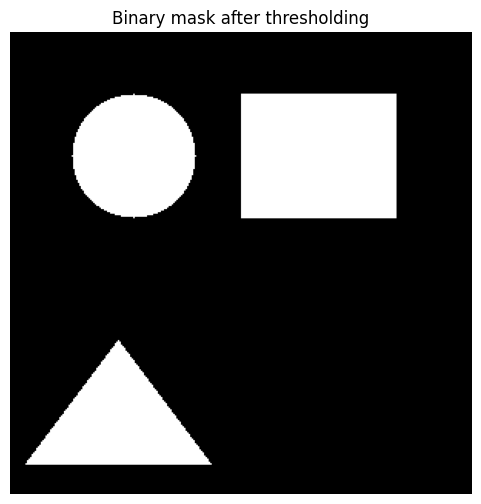

Found 3 objects


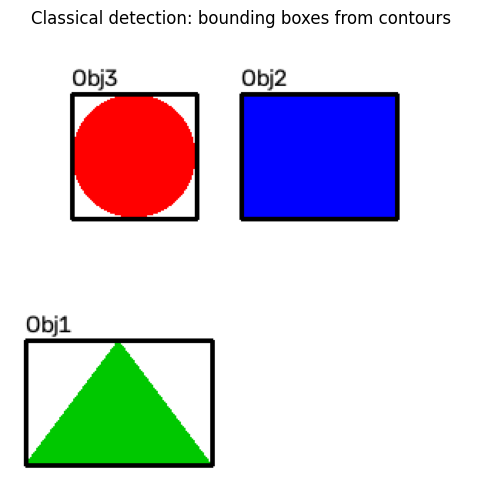

In [4]:
gray = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)

# Anything darker than 240 (i.e., not white background) becomes foreground (255)
_, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
show(thresh, "Binary mask after thresholding")

# RETR_EXTERNAL = only outermost contours; CHAIN_APPROX_SIMPLE = compress contour points
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print(f"Found {len(contours)} objects")

detection_vis = canvas.copy()

for i, c in enumerate(contours):
    x, y, w, h = cv2.boundingRect(c)   # this IS the "bounding box" of object detection

    cv2.rectangle(
        detection_vis,
        (x, y),
        (x + w, y + h),
        (0, 0, 0),
        2
    )

    cv2.putText(
        detection_vis,
        f"Obj{i+1}",
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 0),
        1
    )

show(detection_vis, "Classical detection: bounding boxes from contours")